C:\Users\swarn\AppData\Local\Temp\ipykernel_8804\565396357.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range("2020-01-01", periods=60, freq="M")


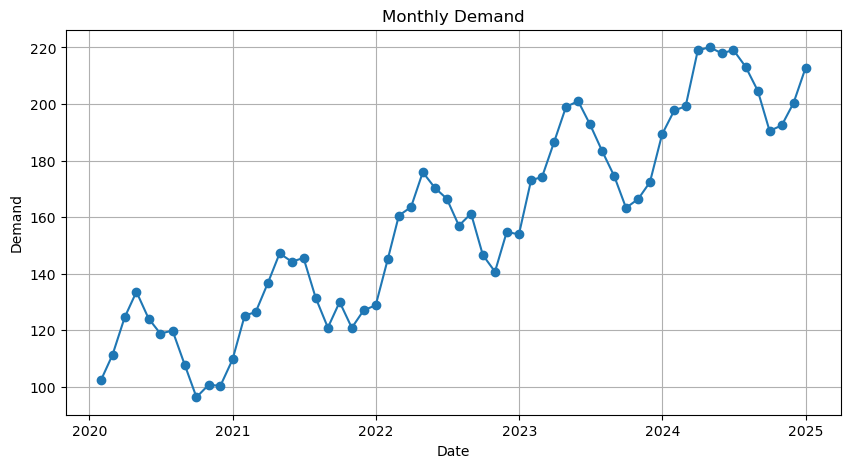


Baseline Forecast
MAE : 17.95
RMSE: 20.82

Moving Average Forecast
MAE : 31.22
RMSE: 32.95

Machine Learning Forecast
MAE : 0.0
RMSE: 0.0


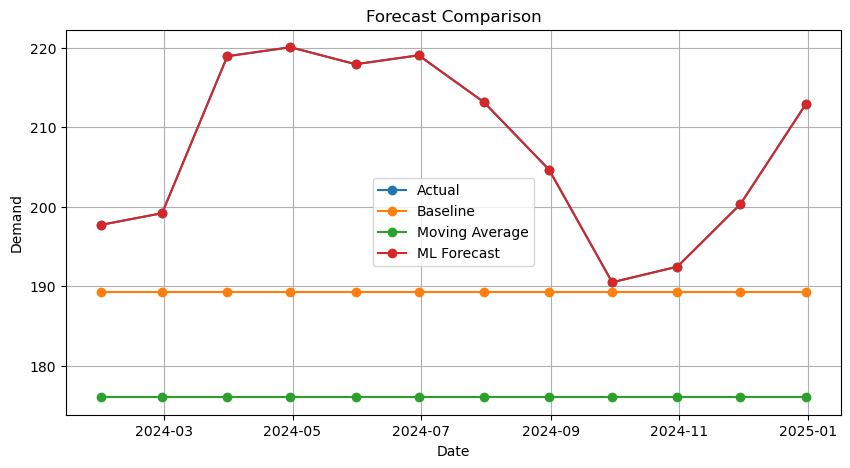

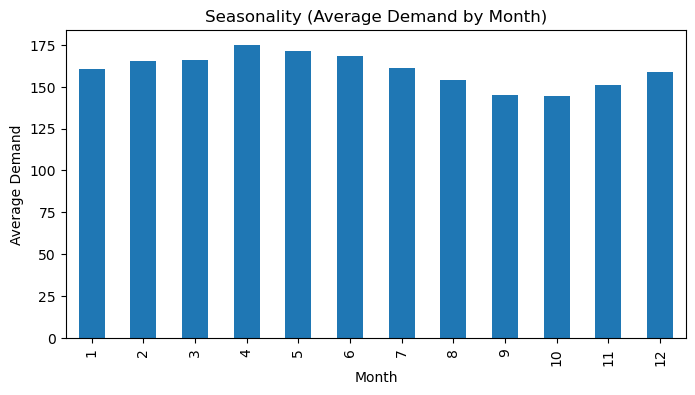


Interpretation
1. Trend: Demand increases over time.
2. Seasonality: Monthly demand follows a repeating yearly pattern.
3. Lag Features: Previous demand values help predict future demand.
4. Rolling Window: 3-month moving average smooths short-term fluctuations.
5. Baseline Forecast: Uses the last observed demand.
6. Moving Average Forecast: Uses the average of the last three months.
7. ML Forecast: Uses lag features and rolling average with Linear Regression.
8. Compare MAE and RMSE to choose the best forecasting method.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------
# Create Monthly Demand Dataset
# -----------------------------
np.random.seed(42)

dates = pd.date_range("2020-01-01", periods=60, freq="M")

trend = np.arange(60) * 2
seasonality = 20 * np.sin(np.arange(60) * 2 * np.pi / 12)
noise = np.random.normal(0, 5, 60)

demand = 100 + trend + seasonality + noise

df = pd.DataFrame({
    "Date": dates,
    "Demand": demand
})

# -----------------------------
# Trend Plot
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["Demand"], marker='o')
plt.title("Monthly Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(True)
plt.show()

# -----------------------------
# Lag Features
# -----------------------------
df["Lag1"] = df["Demand"].shift(1)
df["Lag2"] = df["Demand"].shift(2)

# -----------------------------
# Rolling Window
# -----------------------------
df["Rolling3"] = df["Demand"].rolling(3).mean()

# Remove Missing Values
df = df.dropna()

# -----------------------------
# Train-Test Split
# -----------------------------
train = df.iloc[:-12]
test = df.iloc[-12:]

# -----------------------------
# Baseline Forecast
# -----------------------------
baseline_pred = [train["Demand"].iloc[-1]] * len(test)

# -----------------------------
# Moving Average Forecast
# -----------------------------
moving_avg = train["Demand"].rolling(3).mean().iloc[-1]
moving_pred = [moving_avg] * len(test)

# -----------------------------
# Machine Learning Forecast
# -----------------------------
X_train = train[["Lag1","Lag2","Rolling3"]]
y_train = train["Demand"]

X_test = test[["Lag1","Lag2","Rolling3"]]
y_test = test["Demand"]

model = LinearRegression()
model.fit(X_train, y_train)

ml_pred = model.predict(X_test)

# -----------------------------
# Error Metrics
# -----------------------------
def evaluate(name, actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"\n{name}")
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))

evaluate("Baseline Forecast", y_test, baseline_pred)
evaluate("Moving Average Forecast", y_test, moving_pred)
evaluate("Machine Learning Forecast", y_test, ml_pred)

# -----------------------------
# Forecast Comparison Plot
# -----------------------------
plt.figure(figsize=(10,5))

plt.plot(test["Date"], y_test,
         marker='o', label="Actual")

plt.plot(test["Date"], baseline_pred,
         marker='o', label="Baseline")

plt.plot(test["Date"], moving_pred,
         marker='o', label="Moving Average")

plt.plot(test["Date"], ml_pred,
         marker='o', label="ML Forecast")

plt.title("Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# Trend & Seasonality
# -----------------------------
df["Month"] = df["Date"].dt.month

monthly_avg = df.groupby("Month")["Demand"].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(kind="bar")
plt.title("Seasonality (Average Demand by Month)")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.show()

# -----------------------------
# Interpretation
# -----------------------------
print("\nInterpretation")
print("1. Trend: Demand increases over time.")
print("2. Seasonality: Monthly demand follows a repeating yearly pattern.")
print("3. Lag Features: Previous demand values help predict future demand.")
print("4. Rolling Window: 3-month moving average smooths short-term fluctuations.")
print("5. Baseline Forecast: Uses the last observed demand.")
print("6. Moving Average Forecast: Uses the average of the last three months.")
print("7. ML Forecast: Uses lag features and rolling average with Linear Regression.")
print("8. Compare MAE and RMSE to choose the best forecasting method.")